In [68]:
import pandas as pd
import os
import sys

# Ensure the correct directory paths
init_dir = os.getcwd()
parent_dir = os.path.dirname(init_dir)
mlc_dir = os.path.join(init_dir, "mlc")
sys.path.append(mlc_dir)
# Install the cashflow module if not found
try:
	import cashflow
except ModuleNotFoundError:
	print("Module 'cashflow' not found. Please ensure it exists in the directory:", mlc_dir)

In [69]:
import matplotlib.pyplot as plt
import numpy as np

In [70]:
df_consumers = pd.read_parquet(parent_dir+"/cashflow-data/consumer_data.parquet")
df_transactions = pd.read_parquet(parent_dir+"/cashflow-data/transactions.parquet")

In [71]:
merged_df = df_transactions.merge(df_consumers, on = "masked_consumer_id")
filtered_df = merged_df[merged_df["posted_date"]< merged_df["evaluation_date"]]

In [72]:
filtered_df["loan_type"] = filtered_df["masked_consumer_id"].str[2]
filtered_df["loan_type"] = filtered_df["loan_type"].astype(int)

C:\Users\18585\AppData\Local\Temp\ipykernel_21344\4155308201.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["loan_type"] = filtered_df["masked_consumer_id"].str[2]
C:\Users\18585\AppData\Local\Temp\ipykernel_21344\4155308201.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["loan_type"] = filtered_df["loan_type"].astype(int)


In [73]:
filtered_df

,masked_consumer_id,posted_date,amount,category,masked_transaction_id,evaluation_date,FPF_TARGET,total_balance,loan_type
0,C02103629,2022-08-12,-21.00,27.0,C02T02715977,2022-11-16,1.0,109.53,2
1,C02103629,2022-08-09,-8.60,22.0,C02T02715978,2022-11-16,1.0,109.53,2
2,C02103629,2022-08-07,-30.05,16.0,C02T02715979,2022-11-16,1.0,109.53,2
3,C02103629,2022-09-29,-0.46,0.0,C02T02715980,2022-11-16,1.0,109.53,2
4,C02103629,2022-07-21,-50.00,12.0,C02T02715981,2022-11-16,1.0,109.53,2
...,...,...,...,...,...,...,...,...,...
17737465,C04100783,2022-03-29,-11.20,14.0,C04T01071462,2022-03-31,0.0,1104.86,4
17737466,C04100783,2022-03-29,-1.00,1.0,C04T01071463,2022-03-31,0.0,1104.86,4
17737467,C04100783,2022-03-30,-2.00,1.0,C04T01071464,2022-03-31,0.0,1104.86,4
17737468,C04100783,2022-03-30,-15.00,17.0,C04T01071465,2022-03-31,0.0,1104.86,4


In [74]:
trans_cats = pd.read_csv(parent_dir+"/transaction_categories.csv")
trans_cats

,code,description
0,0,SELF_TRANSFER
1,1,EXTERNAL_TRANSFER
2,2,DEPOSIT
3,3,PAYCHECK
4,4,MISCELLANEOUS
5,5,PAYCHECK_PLACEHOLDER
6,6,REFUND
7,7,INVESTMENT_INCOME
8,8,OTHER_BENEFITS
9,9,UNEMPLOYMENT_BENEFITS


In [75]:
cats_to_codes = dict(zip(trans_cats["description"], trans_cats["code"]))
codes_to_cats = dict(zip(trans_cats["code"], trans_cats["description"]))

dataframes_by_loans is a dictionary. Keys of which correspond to loan type, mapping to the merged dataframe that contains transactions and evaluation data.

In [76]:
dataframes_by_loans = {lt: pd.DataFrame() for lt in filtered_df.loan_type.unique()}
for key in dataframes_by_loans:
    dataframes_by_loans[key] = filtered_df[:][filtered_df.loan_type == key].drop(columns = ["loan_type","masked_transaction_id"])

co2_df = dataframes_by_loans[2]
co2_df["masked_consumer_id"] = co2_df["masked_consumer_id"].str[-4:]
co2_df["evaluation_date"] = pd.to_datetime(co2_df["evaluation_date"])
co2_df["posted_date"] = pd.to_datetime(co2_df["posted_date"])

In [78]:
co2_df = co2_df[abs(co2_df["amount"])>5]

In [79]:
ids_by_transactions = {}
for i in range(36):
    ids_by_transactions[i] = co2_df[co2_df["category"] == i][["masked_consumer_id","FPF_TARGET", "posted_date","amount"]]

In [80]:
co2_df

,masked_consumer_id,posted_date,amount,category,evaluation_date,FPF_TARGET,total_balance
0,3629,2022-08-12,-21.00,27.0,2022-11-16,1.0,109.53
1,3629,2022-08-09,-8.60,22.0,2022-11-16,1.0,109.53
2,3629,2022-08-07,-30.05,16.0,2022-11-16,1.0,109.53
4,3629,2022-07-21,-50.00,12.0,2022-11-16,1.0,109.53
7,3629,2022-10-06,-15.33,1.0,2022-11-16,1.0,109.53
...,...,...,...,...,...,...,...
6648184,1789,2022-08-30,-14.73,16.0,2022-10-31,1.0,0.00
6648185,1789,2022-10-18,-18.71,14.0,2022-10-31,1.0,0.00
6648186,1789,2022-06-30,-5.07,16.0,2022-10-31,1.0,0.00
6648187,1789,2022-08-30,-10.23,16.0,2022-10-31,1.0,0.00


Add final features to the dataframe below

In [81]:
co2_consumers = co2_df[["masked_consumer_id","FPF_TARGET","total_balance","evaluation_date"]].drop_duplicates()
co2_consumers.reset_index(drop=True, inplace=True)
co2_consumers

,masked_consumer_id,FPF_TARGET,total_balance,evaluation_date
0,3629,1.0,109.53,2022-11-16
1,3630,0.0,9.78,2022-12-07
2,3631,0.0,-8.49,2022-11-30
3,3632,0.0,97.75,2023-02-19
4,3633,1.0,0.66,2022-12-21
...,...,...,...,...
3995,1784,0.0,70.97,2023-05-10
3996,1785,0.0,256.14,2023-07-31
3997,1786,1.0,120.66,2023-01-21
3998,1787,1.0,1519.52,2023-01-05


Investigation into rent

In [82]:
consumer_counts = ids_by_transactions[cats_to_codes["RENT"]].groupby("masked_consumer_id").size().reset_index(name="count")
freq_of_counts = consumer_counts["count"].value_counts().sort_index()
freq_of_counts

count
1     179
2      67
3      60
4      46
5      26
6      55
7       9
8      12
9       4
10      5
11      5
12      5
13      1
14      1
16      2
17      1
18      3
19      2
20      1
21      1
22      1
24      1
51      1
Name: count, dtype: int64

Aggregates transactions by month

In [106]:
def agg_rent_with_avg_std(code):
    transactions = ids_by_transactions.get(code, pd.DataFrame()).copy()
    
    # Ensure datetime and drop NaNs
    transactions["posted_date"] = pd.to_datetime(transactions["posted_date"], errors='coerce')
    transactions = transactions.dropna(subset=["posted_date", "amount"])
    
    # Extract month and day
    transactions["month"] = transactions["posted_date"].dt.month
    transactions["day"] = transactions["posted_date"].dt.day.astype(int)
    
    # Step 1: Sum all transactions per consumer-month-target
    monthly_totals = (
        transactions
        .groupby(["masked_consumer_id", "month", "FPF_TARGET"])["amount"]
        .sum()
        .reset_index(name="monthly_total")
    )
    
    # Step 2: Compute average and std of monthly totals per consumer-target
    agg_stats = (
        monthly_totals
        .groupby(["masked_consumer_id", "FPF_TARGET"])["monthly_total"]
        .agg(
            avg_amount="mean",
            std_amount=lambda x: x.std() if len(x) > 1 else 0
        )
        .reset_index()
    )
    
    # Step 3: Compute weighted average day per consumer-target
    weighted_avg_day = (
        transactions
        .groupby(["masked_consumer_id", "FPF_TARGET"])
        .apply(lambda g: (g["day"] * abs(g["amount"])).sum() / abs(g["amount"]).sum())
        .reset_index(name=f"weighted_avg_day_{code}")
    )
    
    # Step 4: Merge avg/std stats with weighted average day
    final_df = agg_stats.merge(weighted_avg_day, on=["masked_consumer_id", "FPF_TARGET"], how="left")
    final_df[f"weighted_avg_day_{code}"] = abs(15.5-final_df[f"weighted_avg_day_{code}"])#distance from middle of month
    final_df[f"avg_amount_{code}"] = final_df["avg_amount"]
    final_df[f"std_amount_{code}"] = final_df["std_amount"]
    final_df = final_df.drop(columns=["avg_amount", "std_amount"])
    final_df = pd.merge(co2_consumers, final_df,
                     on=["masked_consumer_id", "FPF_TARGET"],
                     how="left").fillna(0)
    final_df.drop(columns=["evaluation_date"], inplace=True)
    return final_df

In [108]:
def agg_month_with_avg_std(code, df):
    transactions = ids_by_transactions.get(code, pd.DataFrame()).copy()
    
    # Ensure datetime and drop NaNs
    transactions["posted_date"] = pd.to_datetime(transactions["posted_date"], errors='coerce')
    transactions = transactions.dropna(subset=["posted_date", "amount"])
    
    # Extract month and day
    transactions["month"] = transactions["posted_date"].dt.month
    transactions["day"] = transactions["posted_date"].dt.day.astype(int)
    
    # Step 1: Sum all transactions per consumer-month-target
    monthly_totals = (
        transactions
        .groupby(["masked_consumer_id", "month", "FPF_TARGET"])["amount"]
        .sum()
        .reset_index(name="monthly_total")
    )
    
    # Step 2: Compute average and std of monthly totals per consumer-target
    agg_stats = (
        monthly_totals
        .groupby(["masked_consumer_id", "FPF_TARGET"])["monthly_total"]
        .agg(
            avg_amount="mean",
            std_amount=lambda x: x.std() if len(x) > 1 else 0
        )
        .reset_index()
    )
    
    # Step 3: Compute weighted average day per consumer-target
    weighted_avg_day = (
        transactions
        .groupby(["masked_consumer_id", "FPF_TARGET"])
        .apply(lambda g: (g["day"] * abs(g["amount"])).sum() / abs(g["amount"]).sum())
        .reset_index(name=f"weighted_avg_day_{code}")
    )
    
    # Step 4: Merge avg/std stats with weighted average day
    final_df = agg_stats.merge(weighted_avg_day, on=["masked_consumer_id", "FPF_TARGET"], how="left")
    final_df[f"weighted_avg_day_{code}"] = abs(15.5-final_df[f"weighted_avg_day_{code}"])#distance from middle of month
    final_df[f"avg_amount_{code}"] = final_df["avg_amount"]
    final_df[f"std_amount_{code}"] = final_df["std_amount"]
    final_df = final_df.drop(columns=["avg_amount", "std_amount"])
    final_df = df.merge(final_df, on=["masked_consumer_id", "FPF_TARGET"], how="left").fillna(0)
    return final_df


In [87]:
rent = agg_rent_with_avg_std(cats_to_codes["RENT"])
rent

,masked_consumer_id,FPF_TARGET,total_balance,weighted_avg_day_34,avg_amount_34,std_amount_34
0,3629,1.0,109.53,0.000000,0.000000,0.000000
1,3630,0.0,9.78,0.000000,0.000000,0.000000
2,3631,0.0,-8.49,0.000000,0.000000,0.000000
3,3632,0.0,97.75,0.000000,0.000000,0.000000
4,3633,1.0,0.66,0.000000,0.000000,0.000000
...,...,...,...,...,...,...
3995,1784,0.0,70.97,0.000000,0.000000,0.000000
3996,1785,0.0,256.14,0.000000,0.000000,0.000000
3997,1786,1.0,120.66,0.000000,0.000000,0.000000
3998,1787,1.0,1519.52,0.000000,0.000000,0.000000


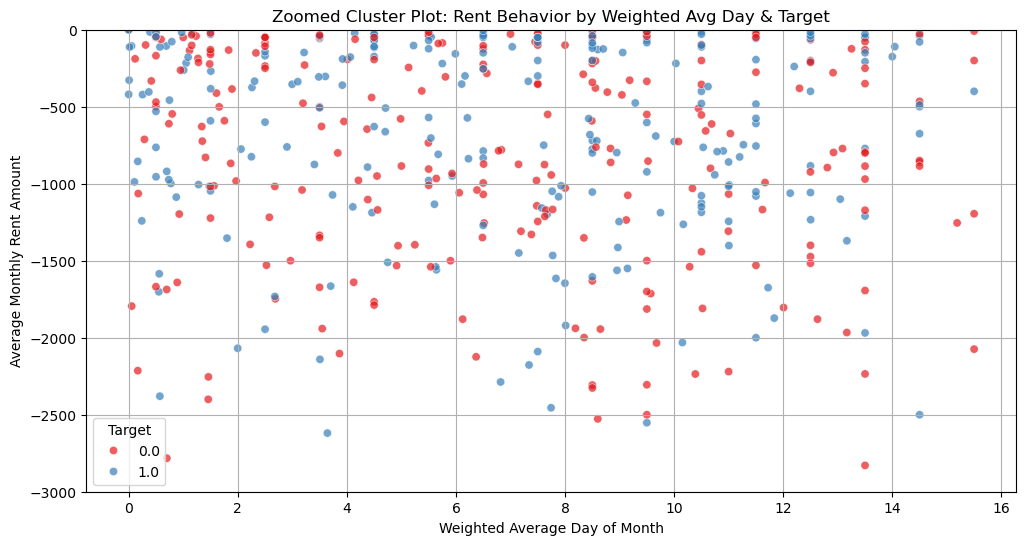

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=rent,
    x="weighted_avg_day_34",
    y="avg_amount_34",
    hue="FPF_TARGET",
    palette="Set1",
    alpha=0.7
)

# Set zoom range
plt.ylim(-3000,0)

plt.xlabel("Weighted Average Day of Month")
plt.ylabel("Average Monthly Rent Amount")
plt.title("Zoomed Cluster Plot: Rent Behavior by Weighted Avg Day & Target")
plt.grid(True)
plt.legend(title="Target")
plt.show()


In [115]:
def get_corr(rent):
    rent_feats = rent.drop(columns=["masked_consumer_id"])
    corr = rent_feats.corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=False, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Matrix")
    plt.show()

In [90]:
# Merge aggregated rent data into the bigger DataFrame
co2_consumers_with_rent = pd.merge(co2_consumers, rent,
                     on=["masked_consumer_id", "FPF_TARGET"],
                     how="left").fillna(0)
co2_consumers_with_rent.drop(columns=["evaluation_date"], inplace=True)
co2_consumers_with_rent

,masked_consumer_id,FPF_TARGET,total_balance_x,total_balance_y,weighted_avg_day_34,avg_amount_34,std_amount_34
0,3629,1.0,109.53,109.53,0.000000,0.000000,0.000000
1,3630,0.0,9.78,9.78,0.000000,0.000000,0.000000
2,3631,0.0,-8.49,-8.49,0.000000,0.000000,0.000000
3,3632,0.0,97.75,97.75,0.000000,0.000000,0.000000
4,3633,1.0,0.66,0.66,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...
3995,1784,0.0,70.97,70.97,0.000000,0.000000,0.000000
3996,1785,0.0,256.14,256.14,0.000000,0.000000,0.000000
3997,1786,1.0,120.66,120.66,0.000000,0.000000,0.000000
3998,1787,1.0,1519.52,1519.52,0.000000,0.000000,0.000000


In [91]:
def plot_cat(code):
    transactions = ids_by_transactions.get(code, pd.DataFrame())
    vol_dfs = {}
    avg_std_by_day = {}
    avg_amt_by_day = {}
    for target in range(2):
        transactions_target = transactions[transactions["FPF_TARGET"] == target].copy()
        transactions_target["posted_date"] = pd.to_datetime(transactions_target["posted_date"], errors='coerce')
        transactions_target = transactions_target.dropna(subset=["posted_date", "amount"])
        transactions_target["day_of_month"] = transactions_target["posted_date"].dt.day
        transactions_target["month"] = transactions_target["posted_date"].dt.month
        # -------------------------
        # 1. Inter-Transaction Volatility
        # -------------------------
        inter_tx_volatility = []

        for cust_id, group in transactions_target.groupby("masked_consumer_id"):
            group = group.sort_values("posted_date")
            time_deltas = group["posted_date"].diff().dropna()
            if len(time_deltas) > 1:
                inter_tx_vol = np.std(time_deltas)
                inter_tx_volatility.append({"masked_consumer_id": cust_id, "inter_tx_volatility": inter_tx_vol})

        inter_tx_df = pd.DataFrame(inter_tx_volatility)

        # -------------------------
        # 2. Transaction Count Volatility
        # -------------------------
        tx_count_volatility = []

        for cust_id, group in transactions_target.groupby("masked_consumer_id"):
            tx_counts = group.groupby(group["posted_date"].dt.date).size()  # Count per date
            if len(tx_counts) > 1:
                count_vol = np.std(tx_counts)
                tx_count_volatility.append({"masked_consumer_id": cust_id, "tx_count_volatility": count_vol})

        tx_count_df = pd.DataFrame(tx_count_volatility)

        # -------------------------
        # Merge and Inspect
        # -------------------------
        combined_df = pd.merge(inter_tx_df, tx_count_df, on="masked_consumer_id", how="outer")
        print(f"\nTarget = {target}")
        print(combined_df.describe())
        vol_dfs[target] = combined_df
        # -------------------------
        # Scatter Plot (Amount vs Day of Month)
        # -------------------------
        plt.figure(figsize=(10, 6))
        plt.scatter(transactions_target["day_of_month"], transactions_target["amount"], alpha=0.5)
        plt.xlabel("Day of Month")
        plt.ylabel("Transaction Amount")
        plt.title(f"Scatter: Target = {target} for {codes_to_cats.get(code, code)}")
        plt.show()

        # -------------------------
        # Histogram of Day of Month
        # -------------------------
        plt.figure(figsize=(10, 6))
        plt.hist(transactions_target["day_of_month"], bins=30, color='skyblue', edgecolor='black')
        plt.xlabel("Day of Month")
        plt.ylabel("Frequency")
        plt.title(f"Histogram of {codes_to_cats.get(code, code)} by DoM for Target {target}")
        plt.show()

        # -------------------------
        # Std Dev of Amount per Consumer per Day
        # -------------------------
        std_per_consumer = (
            transactions_target.groupby(["masked_consumer_id", "day_of_month"])["amount"]
            .std()
            .reset_index(name="std_amount")
        )
        # Compute average amount per consumer
        monthwise_per_consumer = agg_month_with_avg_std(code)
        avg_amount_per_consumer = (
            monthwise_per_consumer.groupby("masked_consumer_id")["amount"]
            .mean()
            .rename("avg_amount")
            .reset_index()
        )

        # Merge with std dev dataframe
        std_per_consumer = std_per_consumer.merge(avg_amount_per_consumer, on="masked_consumer_id")

        avg_std_by_day[target] = std_per_consumer.groupby("day_of_month")["std_amount"].mean()
        avg_amt_by_day[target] = std_per_consumer.groupby("day_of_month")["avg_amount"].mean()
        plt.figure(figsize=(10, 6))
        plt.plot(avg_amt_by_day[target].index, avg_amt_by_day[target].values, marker='o', color='orange')
        plt.xlabel("Day of Month")
        plt.ylabel("Avg Std Dev of Amounts")
        plt.title(f"Avg Amount Std Dev per DoM for Target = {target} in {codes_to_cats.get(code, code)}")
        plt.show()
    return vol_dfs, avg_amt_by_day


In [92]:
# vol_rent, avg_rent_amt = plot_cat(cats_to_codes["RENT"])
# for i in range(2):
#     print(f"Target = {i}")
#     print(vol_rent[i])
#     print(avg_rent_amt[i])

In [93]:
def plot_cat_month(code):
    transactions = ids_by_transactions.get(code, pd.DataFrame())
    std_by_month = {}
    avg_by_month = {}

    for target in range(2):
        transactions_target = transactions[transactions["FPF_TARGET"] == target].copy()
        transactions_target["posted_date"] = pd.to_datetime(transactions_target["posted_date"], errors='coerce')
        transactions_target = transactions_target.dropna(subset=["posted_date", "amount"])

        transactions_target["month"] = transactions_target["posted_date"].dt.month

        # 1. Aggregate per consumer per month 
        monthly_avg = (
            transactions_target.groupby(["masked_consumer_id", "month"])["amount"]
            .sum()
            .reset_index(name="monthly_avg")
        )

        # 2. Now compute std deviation across months per consumer
        std_per_consumer = (
            monthly_avg.groupby("masked_consumer_id")["monthly_avg"]
            .agg(std_amount=lambda x: x.std() if len(x) > 1 else 0)
            .reset_index()
        )

        # 3. Also return average across months per consumer
        avg_amount_per_consumer = (
            monthly_avg.groupby("masked_consumer_id")["monthly_avg"]
            .mean()
            .reset_index(name="avg_amount")
        )

        std_by_month[target] = std_per_consumer
        avg_by_month[target] = avg_amount_per_consumer

    return std_by_month, avg_by_month


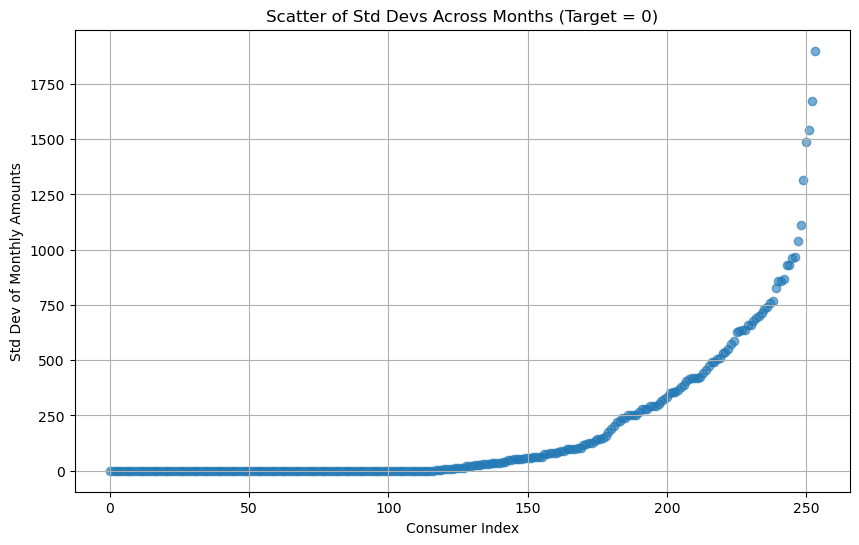

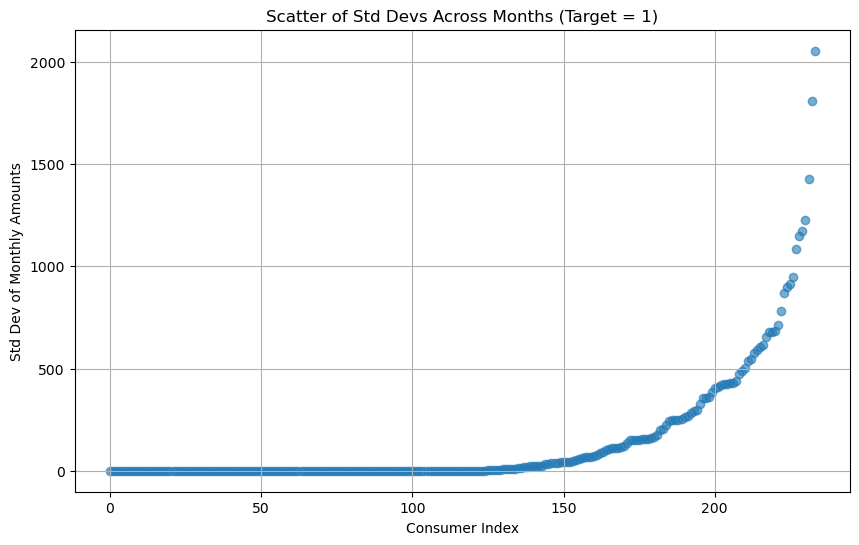

In [94]:
def plot_std_scatter(std_by_month):
    for target, df in std_by_month.items():
        df = df.sort_values("std_amount").reset_index(drop=True)
        plt.figure(figsize=(10, 6))
        plt.scatter(range(len(df)), df["std_amount"], alpha=0.6)
        plt.xlabel("Consumer Index")
        plt.ylabel("Std Dev of Monthly Amounts")
        plt.title(f"Scatter of Std Devs Across Months (Target = {target})")
        plt.grid(True)
        plt.show()
        
std_by_month, avg_by_month = plot_cat_month(cats_to_codes["RENT"])
plot_std_scatter(std_by_month)


In [95]:
std , avg = plot_cat_month(cats_to_codes["RENT"])
for i in range(2):
    print(f"Target = {i}")
    print(std[i])
    print(avg[i])

Target = 0
    masked_consumer_id   std_amount
0                 0005   189.556269
1                 0054     0.000000
2                 0063   277.185858
3                 0068    10.903587
4                 0070    51.350094
..                 ...          ...
249               4949   277.489914
250               4955  1540.000000
251               4979   733.283552
252               4980    11.667262
253               4983     0.000000

[254 rows x 2 columns]
    masked_consumer_id  avg_amount
0                 0005    -405.286
1                 0054     -45.060
2                 0063   -1041.000
3                 0068     -28.130
4                 0070   -1473.560
..                 ...         ...
249               4949    -628.815
250               4955   -3295.000
251               4979   -1013.954
252               4980    -674.250
253               4983  -17300.000

[254 rows x 2 columns]
Target = 1
    masked_consumer_id  std_amount
0                 0062    0.000000
1       

In [96]:
co2_df[(co2_df["category"]==0.0) & (abs(co2_df["amount"])<2)]["amount"]

Series([], Name: amount, dtype: float64)

Aggregating weekly data, Weekday/Weekend classification

In [97]:
co2_df["day_type"] = co2_df["posted_date"].dt.dayofweek
co2_day = co2_df[abs(co2_df["amount"])>5].drop(columns=["posted_date"]).copy()
co2_day

C:\Users\18585\AppData\Local\Temp\ipykernel_21344\2647576327.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  co2_df["day_type"] = co2_df["posted_date"].dt.dayofweek


,masked_consumer_id,amount,category,evaluation_date,FPF_TARGET,total_balance,day_type
0,3629,-21.00,27.0,2022-11-16,1.0,109.53,4
1,3629,-8.60,22.0,2022-11-16,1.0,109.53,1
2,3629,-30.05,16.0,2022-11-16,1.0,109.53,6
4,3629,-50.00,12.0,2022-11-16,1.0,109.53,3
7,3629,-15.33,1.0,2022-11-16,1.0,109.53,3
...,...,...,...,...,...,...,...
6648184,1789,-14.73,16.0,2022-10-31,1.0,0.00,1
6648185,1789,-18.71,14.0,2022-10-31,1.0,0.00,1
6648186,1789,-5.07,16.0,2022-10-31,1.0,0.00,3
6648187,1789,-10.23,16.0,2022-10-31,1.0,0.00,1


In [98]:
transactions_by_cat_day = {}
for i in range(36):
    transactions_by_cat_day[i] = co2_day[co2_day["category"] == i][["masked_consumer_id","FPF_TARGET", "amount","total_balance","day_type"]]

In [99]:
def plot_cat_week(code):
    transactions = transactions_by_cat_day.get(code, pd.DataFrame())
    avg_std_by_day = {}
    avg_amt_by_day = {}
    for target in range(2):
        transactions_target = transactions[transactions["FPF_TARGET"] == target].copy()
        transactions_target = transactions_target.dropna(subset=["amount"])
        # -------------------------
        # Scatter Plot (Amount vs Day of Week)
        # -------------------------
        plt.figure(figsize=(10, 6))
        plt.scatter(transactions_target["day_type"], transactions_target["amount"], alpha=0.5)
        plt.xlabel("Day of Week")
        plt.ylabel("Transaction Amount")
        plt.title(f"Scatter: Target = {target} for {codes_to_cats.get(code, code)}")
        plt.show()

        # -------------------------
        # Histogram of Day of Week
        # -------------------------
        plt.figure(figsize=(10, 6))
        plt.hist(transactions_target["day_type"], bins=30, color='skyblue', edgecolor='black')
        plt.xlabel("Day of Week")
        plt.ylabel("Frequency")
        plt.title(f"Histogram of {codes_to_cats.get(code, code)} by DoM for Target {target}")
        plt.show()

        # -------------------------
        # Std Dev of Amount per Consumer per Day
        # -------------------------
        std_per_consumer = (
            transactions_target.groupby(["masked_consumer_id", "day_type"])["amount"]
            .std()
            .reset_index(name="std_amount")
        )
        # Compute average amount per consumer
        avg_amt = (
        transactions_target.groupby(["masked_consumer_id", "day_type"])["amount"]
        .mean()
        .reset_index(name="avg_amount")
    )

        # Merge with std dev dataframe
        std_per_consumer = std_per_consumer.merge(avg_amt, on=["masked_consumer_id", "day_type"])

        avg_std_by_day[target] = std_per_consumer.groupby("day_type")["std_amount"].mean()
        avg_amt_by_day[target] = std_per_consumer.groupby("day_type")["avg_amount"].mean()
        plt.figure(figsize=(10, 6))
        plt.plot(avg_std_by_day[target].index, avg_std_by_day[target].values, marker='o', color='orange')
        plt.xlabel("Day of Week")
        plt.ylabel("Avg Std Dev of Amounts")
        plt.title(f"Avg Amount Std Dev per DoM for Target = {target} in {codes_to_cats.get(code, code)}")
        plt.show()
    return avg_std_by_day, avg_amt_by_day

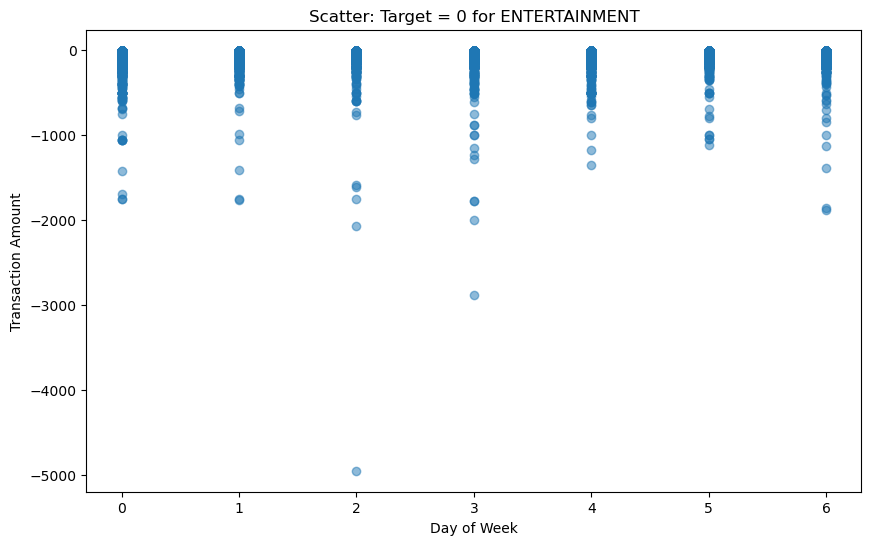

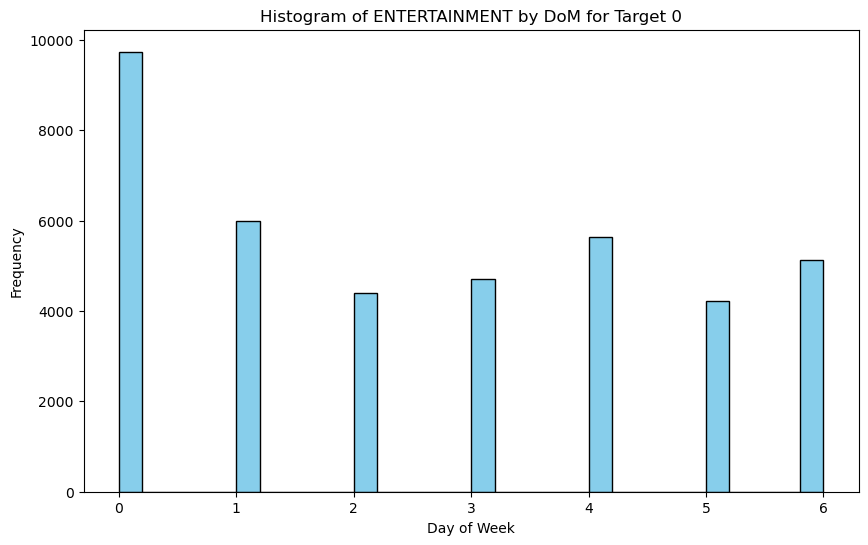

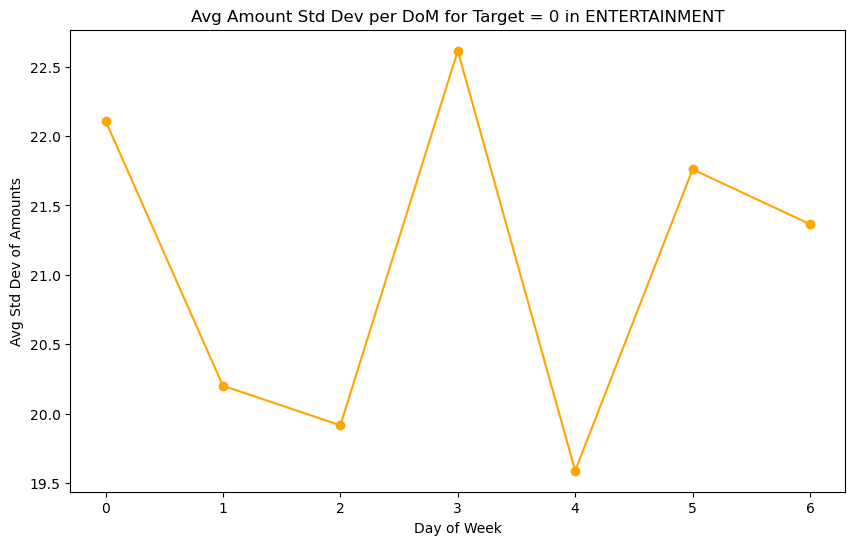

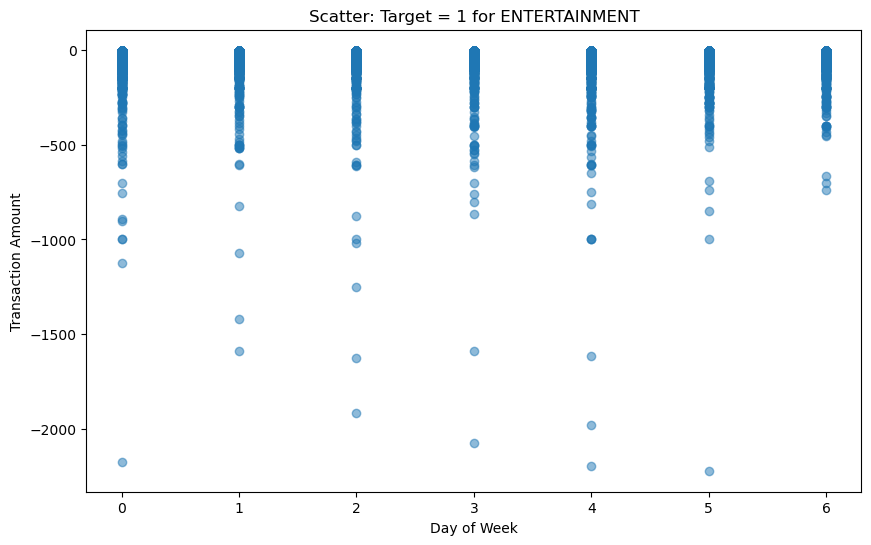

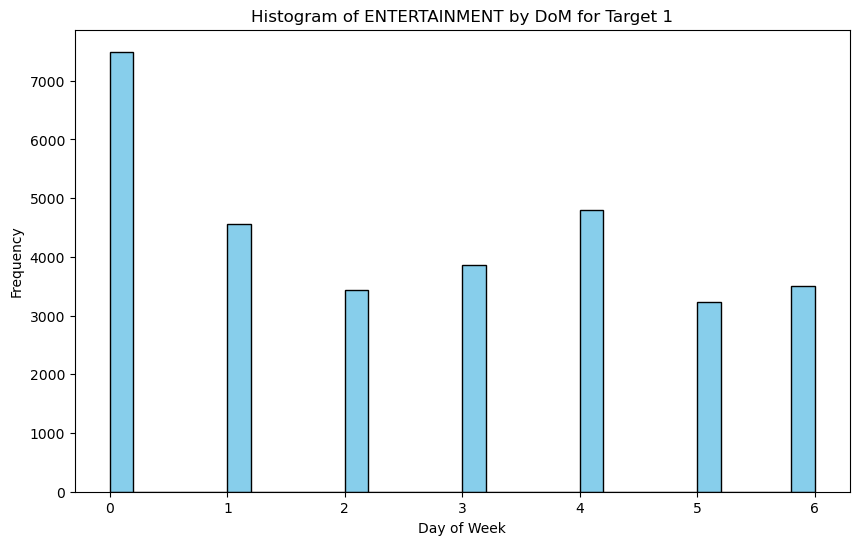

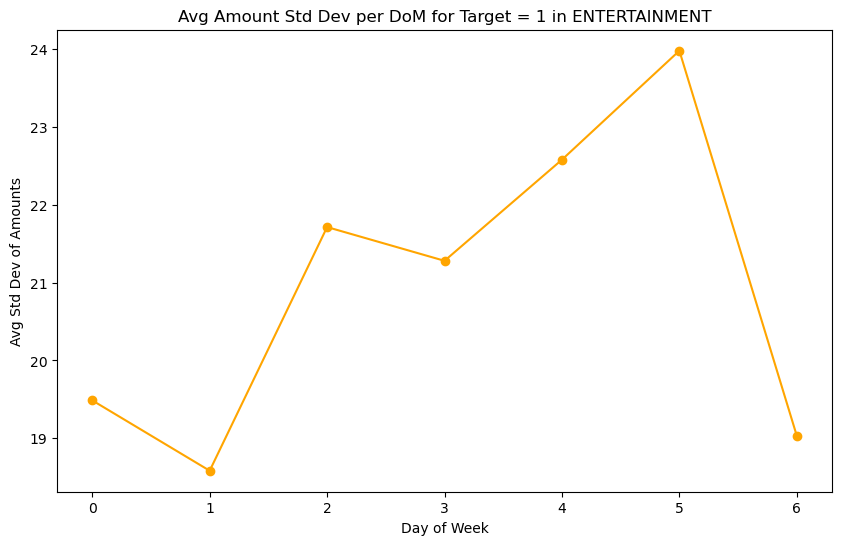

{0: day_type
0    22.110255
1    20.201031
2    19.915961
3    22.614622
4    19.588724
5    21.759994
6    21.365045
Name: std_amount, dtype: float64, 1: day_type
0    19.486593
1    18.582600
2    21.714104
3    21.280456
4    22.579982
5    23.980622
6    19.031377
Name: std_amount, dtype: float64}
{0: day_type
0   -27.951574
1   -27.867095
2   -31.471172
3   -35.817035
4   -28.316563
5   -28.136751
6   -29.176737
Name: avg_amount, dtype: float64, 1: day_type
0   -26.284854
1   -27.334238
2   -26.975303
3   -27.238800
4   -29.353397
5   -30.458496
6   -27.173054
Name: avg_amount, dtype: float64}


In [100]:
avg_std_by_day, avg_amt_by_day = plot_cat_week(cats_to_codes["ENTERTAINMENT"])
print(avg_std_by_day)
print(avg_amt_by_day)

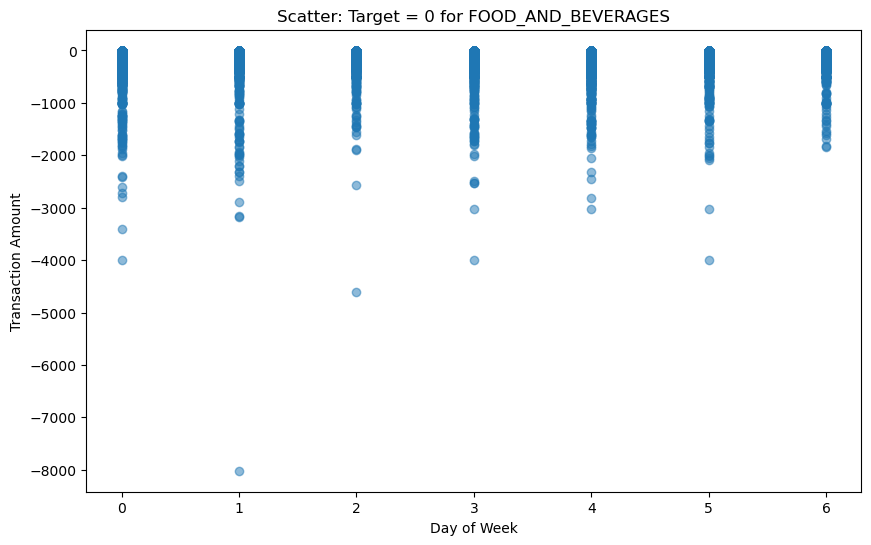

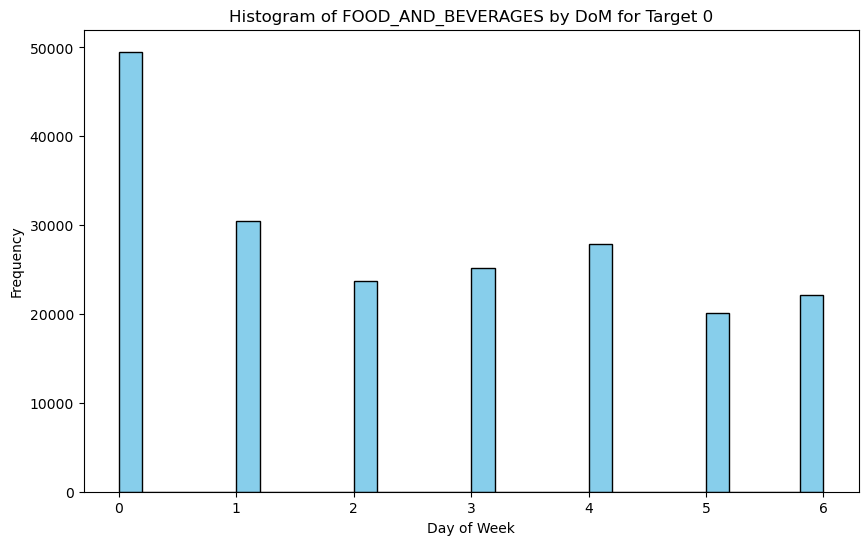

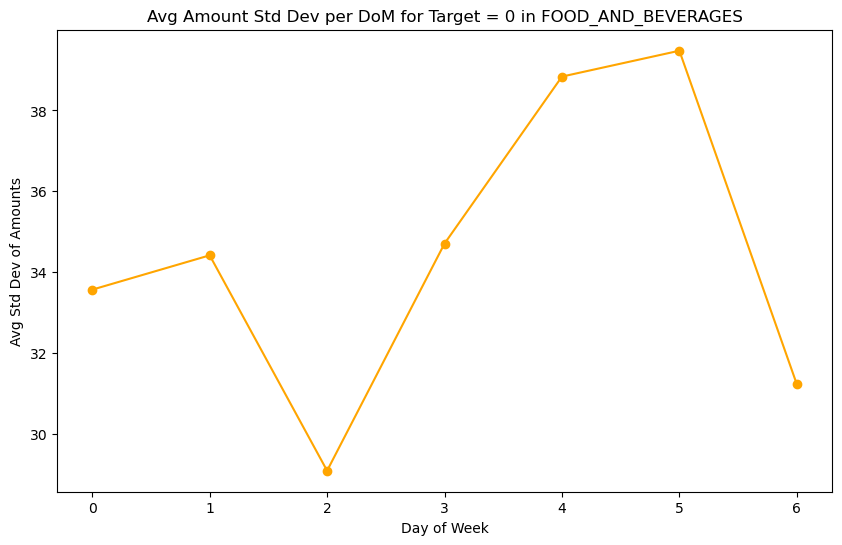

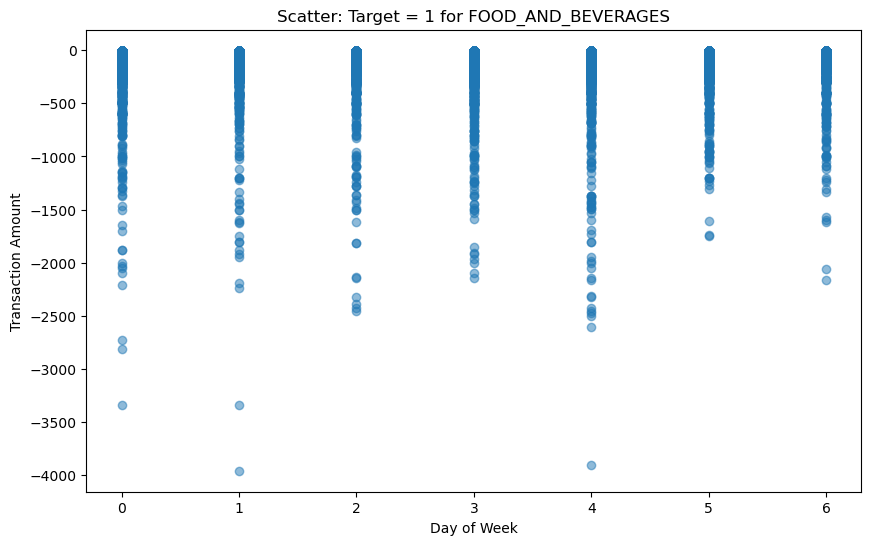

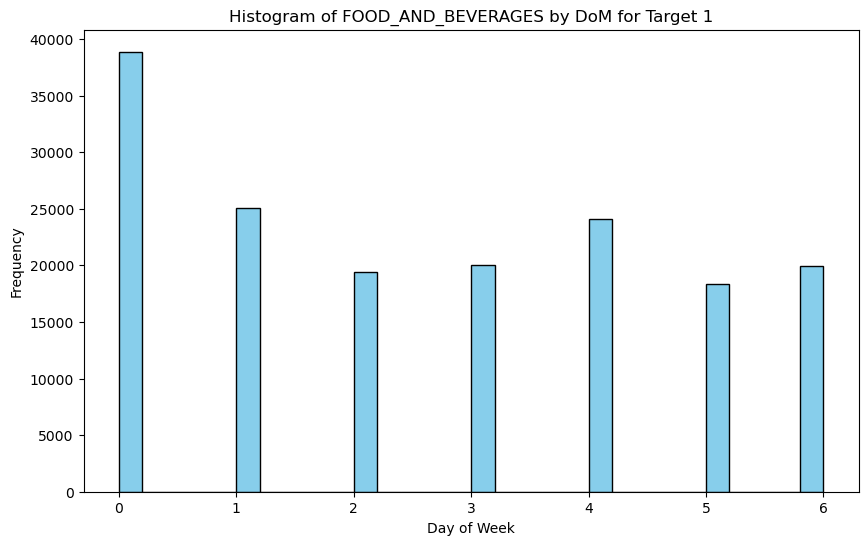

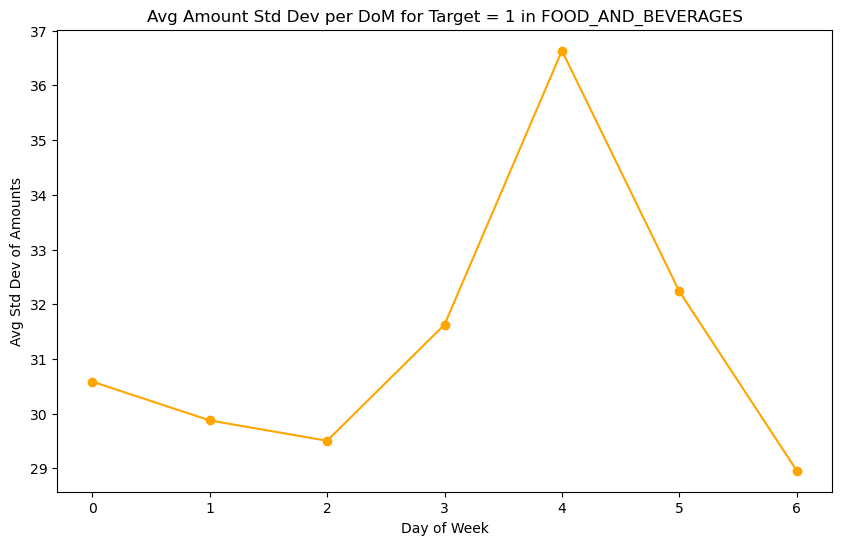

{0: day_type
0    33.570009
1    34.418599
2    29.092971
3    34.709513
4    38.838068
5    39.477722
6    31.232122
Name: std_amount, dtype: float64, 1: day_type
0    30.585474
1    29.876529
2    29.503804
3    31.627017
4    36.632953
5    32.232834
6    28.956899
Name: std_amount, dtype: float64}
{0: day_type
0   -31.631715
1   -31.381287
2   -29.086657
3   -34.322901
4   -34.931020
5   -35.204697
6   -31.326113
Name: avg_amount, dtype: float64, 1: day_type
0   -31.260648
1   -31.686886
2   -30.177478
3   -32.408053
4   -33.987907
5   -31.555758
6   -29.185969
Name: avg_amount, dtype: float64}


In [101]:
avg_std_by_day, avg_amt_by_day = plot_cat_week(cats_to_codes["FOOD_AND_BEVERAGES"])
print(avg_std_by_day)
print(avg_amt_by_day)

Features to consider

In [111]:
monthly_cats = [0,1,2,3,4,5,10,12,13,7,8,19,17,26,29,31,32,33,35] #monthly seasonal
weekly_cats = [0,1,2,3,4,5,7,8,9,10,14,16,17,18,19,20,22,28,33,35] #weekly seasonal
blip_cats = [6,10,15,16,21,23,24,25,27,30] #sporadic and more likely to cause defaults

In [132]:
month_df = rent.copy()
for code in monthly_cats:
    month_df = agg_month_with_avg_std(code, month_df)
    print(code)

0
1
2
3
4
5
10
12
13
7
8
19
17
26
29
31
32
33
35


In [133]:
month_df

,masked_consumer_id,FPF_TARGET,total_balance,weighted_avg_day_34,avg_amount_34,std_amount_34,weighted_avg_day_0,avg_amount_0,std_amount_0,weighted_avg_day_1,...,std_amount_31,weighted_avg_day_32,avg_amount_32,std_amount_32,weighted_avg_day_33,avg_amount_33,std_amount_33,weighted_avg_day_35,avg_amount_35,std_amount_35
0,3629,1.0,109.53,0.000000,0.000000,0.000000,8.475188,150.850000,95.150920,9.823288,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
1,3630,0.0,9.78,0.000000,0.000000,0.000000,2.901328,114.241667,54.958561,2.349159,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
2,3631,0.0,-8.49,0.000000,0.000000,0.000000,1.901829,-2252.333333,1551.321587,1.867920,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
3,3632,0.0,97.75,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.173932,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
4,3633,1.0,0.66,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.048301,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1784,0.0,70.97,0.000000,0.000000,0.000000,7.576856,51.723333,40.015742,0.933394,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
3996,1785,0.0,256.14,0.000000,0.000000,0.000000,3.166667,300.000000,0.000000,0.844727,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
3997,1786,1.0,120.66,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.910624,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.591846,-64.673333,66.701365
3998,1787,1.0,1519.52,0.000000,0.000000,0.000000,2.463566,1725.242857,758.908167,1.251614,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000


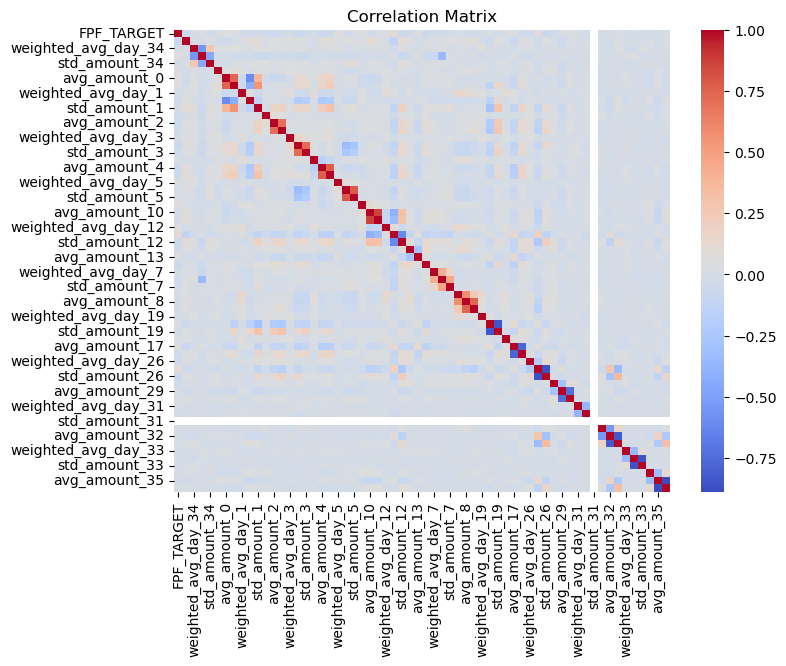

In [134]:
get_corr(month_df)

Aggregate analysis for week-wise features

In [130]:
def agg_week_with_avg_std(code, df):
    transactions = ids_by_transactions.get(code, pd.DataFrame()).copy()
    
    # Ensure datetime and drop NaNs
    transactions["posted_date"] = pd.to_datetime(transactions["posted_date"], errors='coerce')
    transactions = transactions.dropna(subset=["posted_date", "amount"])
    
    transactions["day"] = transactions["posted_date"].dt.dayofweek.astype(int)
    
    # Sum all transactions per consumer-daytype-target
    daily_totals = (
        transactions
        .groupby(["masked_consumer_id", "day", "FPF_TARGET"])["amount"]
        .sum()
        .reset_index(name="weekday_total")
    )
    
    #Compute average and std of daytype totals per consumer-target
    agg_stats = (
        daily_totals
        .groupby(["masked_consumer_id", "FPF_TARGET"])["weekday_total"]
        .agg(
            avg_amount="mean",
            std_amount=lambda x: x.std() if len(x) > 1 else 0
        )
        .reset_index()
    )
    
    #Compute weighted average day per consumer-target
    weighted_avg_day = (
        transactions
        .groupby(["masked_consumer_id", "FPF_TARGET"])
        .apply(lambda g: (g["day"] * abs(g["amount"])).sum() / abs(g["amount"]).sum())
        .reset_index(name=f"weighted_avg_day_{code}")
    )
    
    # Step 4: Merge avg/std stats with weighted average day
    final_df = agg_stats.merge(weighted_avg_day, on=["masked_consumer_id", "FPF_TARGET"], how="left")
    final_df[f"avg_week_amount_{code}"] = final_df["avg_amount"]
    final_df[f"std_week_amount_{code}"] = final_df["std_amount"]
    final_df = final_df.drop(columns=["avg_amount", "std_amount"])
    final_df = df.merge(final_df, on=["masked_consumer_id", "FPF_TARGET"], how="left").fillna(0)
    return final_df


In [137]:
week_df = co2_consumers.copy()
for code in weekly_cats:
    week_df = agg_week_with_avg_std(code, week_df)
    print(code)

0
1
2
3
4
5
7
8
9
10
14
16
17
18
19
20
22
28
33
35


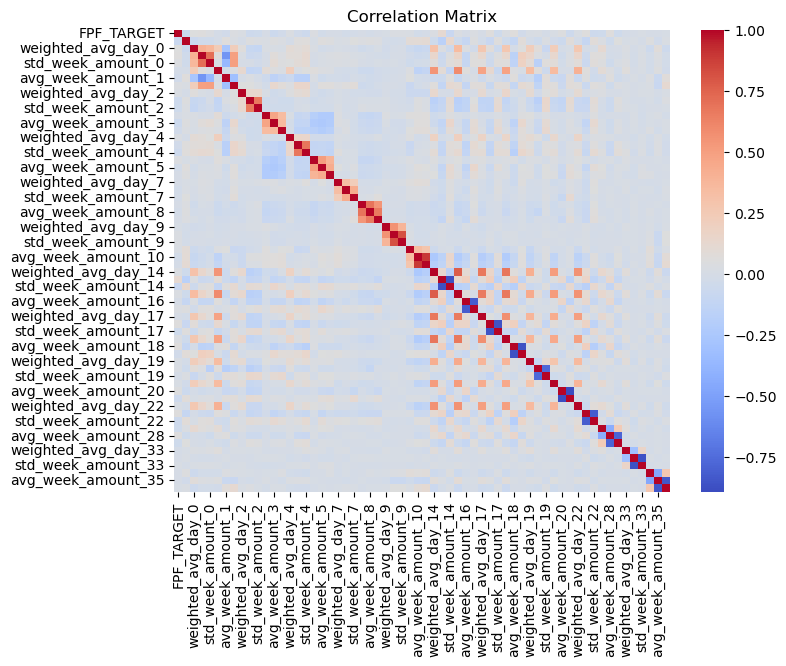

In [143]:
get_corr(week_df)